In [23]:
import numpy as np
from scipy.stats import zipf, entropy
from scipy.stats import chisquare, kstest
from scipy.spatial.distance import jensenshannon

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

In [ ]:
def empirical_distribution(lbas):
    bin_size=65536
    max_lba=15627976704
    bins = np.arange(0, max_lba + bin_size, bin_size)
    hist, _ = np.histogram(lbas, bins=bins)
    # Filter out empty bins for fair comparison
    emp_probs = hist / hist.sum()
    nonzero = emp_probs > 0
    emp_probs = emp_probs[nonzero]
    nbins = len(emp_probs)
    # --- Candidate distributions ---
    # Uniform
    uniform_probs = np.ones(nbins) / nbins

    # Zipf (rank-based)
    ranks = np.arange(1, nbins + 1)
    zipf_s = 1.8
    zipf_probs = zipf.pmf(ranks, a=zipf_s)
    zipf_probs /= zipf_probs.sum()

    # Zoned (hot zones get more traffic)
    n_zones = 29878
    #zoned_probs = np.ones(nbins) * 0.02
    #hot_bins = np.linspace(0, nbins-1, n_zones, dtype=int)
    #zoned_probs[hot_bins] += 1
    #zoned_probs /= zoned_probs.sum()
    #split = int(num_bins * ratio[0])
    ratio = [0.6, 0.4]
    split = int(nbins * ratio[0])
    zoned_probs = np.zeros(nbins)
    zoned_probs[:split] = ratio[0] / split
    zoned_probs[split:] = ratio[1] / (nbins - split)



    # --- Similarity (KL divergence) ---
    kl_uniform = entropy(emp_probs, uniform_probs)
    kl_zipf = entropy(emp_probs, zipf_probs)
    kl_zoned = entropy(emp_probs, zoned_probs)

    results = {
        "Uniform": kl_uniform,
        "Zipfian": kl_zipf,
        "Zoned": kl_zoned
    }
    closest = min(results, key=results.get)
    print("KL Divergence scores (lower is better):")
    for k, v in results.items():
        print(f"  {k:8s}: {v:.4f}")
    print(f"\n👉 Closest match: {closest}")


    chi2_uniform = chisquare(emp_probs, f_exp=uniform_probs)
    chi2_zipf = chisquare(emp_probs, f_exp=zipf_probs)
    chi2_zoned = chisquare(emp_probs, f_exp=zoned_probs)
    print("Chi-square vs Uniform:", chi2_uniform.statistic)
    print("Chi-square vs Zipf:", chi2_zipf.statistic)
    print("Chi-square vs zoned:", chi2_zoned.statistic)


    js_uniform = jensenshannon(emp_probs, uniform_probs) ** 2  # Jensen-Shannon Divergence
    js_zipf = jensenshannon(emp_probs, zipf_probs) ** 2  # Jensen-Shannon Divergence
    js_zoned = jensenshannon(emp_probs, zoned_probs) ** 2  # Jensen-Shannon Divergence
    print("Jensen-Shannon -> uniform", js_uniform)
    print("JensenShanno -> zipf", js_zipf)
    print("JensenShanno -> zoned", js_zoned)


    # --- Plot distributions ---
    plt.figure(figsize=(8, 5))
    plt.plot(emp_probs, label="Empirical", lw=2)
    plt.plot(uniform_probs, label="Uniform", ls="--")
    plt.plot(zipf_probs, label=f"Zipf(s={zipf_s})", ls="-.")
    plt.plot(zoned_probs, label="Zoned", ls=":")

    plt.yscale("log")
    plt.xlabel("Bin index (sorted)")
    plt.ylabel("Probability")
    plt.title("LBA Access Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [25]:
def parse_lba_len_file(filename):
    lbas = []
    lens = []
    
    # regex for "lba: number" and "len: number"
    pattern = re.compile(r"lba:\s*(\d+).*?len:\s*(\d+)")
    expanded_lbas = []
    with open(filename, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                lba_start = int(match.group(1))
                length = int(match.group(2))
                lbas.append(lba_start)
                lens.append(length)
                #
                #expanded_lbas.extend(range(lba_start, lba_start + length))
    
    # build DataFrame
    df = pd.DataFrame({
        "lba": lbas,
        "len": lens
    })
    repeated_starts = np.repeat(df['lba'].values, df['len'].values)
    expanded_df = pd.DataFrame({'lba': repeated_starts})
    
    
    #return df
    return expanded_df

KL Divergence scores (lower is better):
  Uniform : 0.0235
  Zipfian : 5.6417
  Zoned   : 0.0235

👉 Closest match: Zoned
Chi-square vs Uniform: 0.028940861555894357
Chi-square vs Zipf: 607.6720858329202
Chi-square vs zoned: 0.02893978977434291


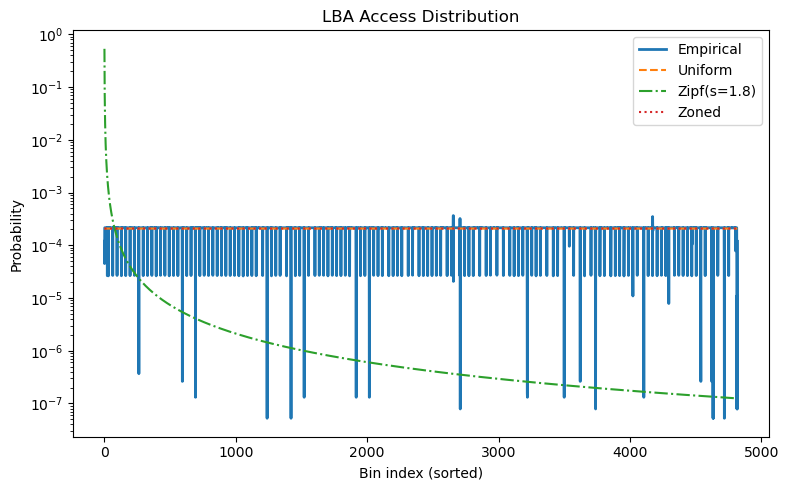

In [26]:
#lbas_len =['lbas', 'len']
#lbas = ['lbas']
#lbas_len_df = parse_lba_len_file('/home/surbhi/measurements/zfs-resilvering-wb/io-pattern/dmesg_resilveringLBAS')
#lbas = lbas_len_df['lba'].to_numpy()
df = parse_lba_len_file('/home/surbhi/measurements/zfs-resilvering-wb/io-pattern/dmesg_resilveringLBAS')
lbas = df['lba'].to_numpy()
empirical_distribution(lbas)
